In [1]:
# ─────────────────────────────────────────────────────────────
# STEP 2 — DATA UNDERSTANDING
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("=" * 60)
print("STEP 2 — DATA UNDERSTANDING")
print("=" * 60)

# ── Load the main training table ──────────────────────────────
df = pd.read_csv("D:\\home-credit-default-risk\\data\\application_train.csv")

STEP 2 — DATA UNDERSTANDING


In [2]:
df.shape

(307511, 122)

In [3]:
# ─────────────────────────────────────────────────────────────
# 2A. BASIC SHAPE & COLUMN TYPES
# ─────────────────────────────────────────────────────────────

print("\n[2A] COLUMN DATA TYPES")
print("-" * 40)
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):<15} : {count} columns")

numerical_cols   = df.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Remove target from feature lists
numerical_cols = [c for c in numerical_cols if c != "TARGET"]

print(f"\n  Numerical columns   : {len(numerical_cols)}")
print(f"  Categorical columns : {len(categorical_cols)}")


[2A] COLUMN DATA TYPES
----------------------------------------
  float64         : 65 columns
  int64           : 41 columns
  object          : 16 columns

  Numerical columns   : 105
  Categorical columns : 16



[2B] MISSING VALUES — TOP 20 COLUMNS
----------------------------------------
  Total columns with missing values: 67

  Column                                         Missing %      Count
  -------------------------------------------------------------------
  COMMONAREA_MEDI                                   69.9%    214,865
  COMMONAREA_AVG                                    69.9%    214,865
  COMMONAREA_MODE                                   69.9%    214,865
  NONLIVINGAPARTMENTS_MODE                          69.4%    213,514
  NONLIVINGAPARTMENTS_AVG                           69.4%    213,514
  NONLIVINGAPARTMENTS_MEDI                          69.4%    213,514
  FONDKAPREMONT_MODE                                68.4%    210,295
  LIVINGAPARTMENTS_MODE                             68.4%    210,199
  LIVINGAPARTMENTS_AVG                              68.4%    210,199
  LIVINGAPARTMENTS_MEDI                             68.4%    210,199
  FLOORSMIN_AVG                                   

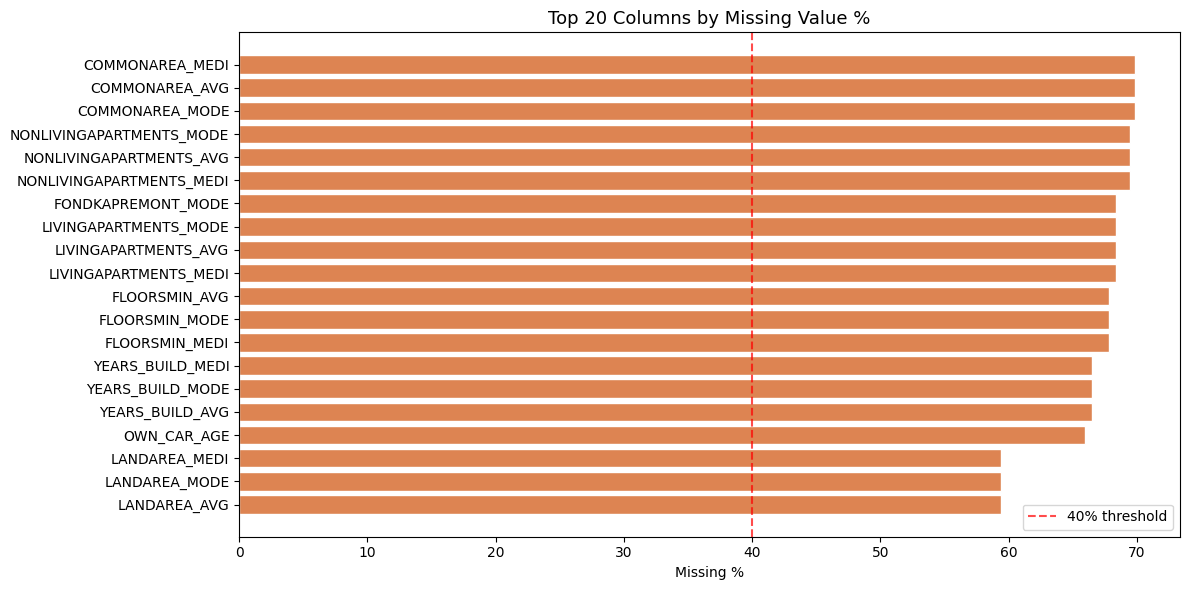


  Chart saved: missing_values.png


In [4]:
# ─────────────────────────────────────────────────────────────
# 2B. MISSING VALUES
# ─────────────────────────────────────────────────────────────

print("\n[2B] MISSING VALUES — TOP 20 COLUMNS")
print("-" * 40)

missing = df.isnull().mean().sort_values(ascending=False)
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_df = pd.DataFrame({
    "missing_pct"   : missing,
    "missing_count" : missing_count
}).query("missing_pct > 0")

print(f"  Total columns with missing values: {len(missing_df)}")
print(f"\n  {'Column':<45} {'Missing %':>10} {'Count':>10}")
print("  " + "-" * 67)
for col, row in missing_df.head(20).iterrows():
    print(f"  {col:<45} {row['missing_pct']:>9.1%} {int(row['missing_count']):>10,}")

# Plot top 20 missing
fig, ax = plt.subplots(figsize=(12, 6))
top20_missing = missing_df.head(20)
bars = ax.barh(
    top20_missing.index[::-1],
    top20_missing["missing_pct"].values[::-1] * 100,
    color="#DD8452", edgecolor="white"
)
ax.set_xlabel("Missing %")
ax.set_title("Top 20 Columns by Missing Value %", fontsize=13)
ax.axvline(x=40, color="red", linestyle="--", alpha=0.7, label="40% threshold")
ax.legend()
plt.tight_layout()
plt.savefig("missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: missing_values.png")


[2C] KEY NUMERICAL FEATURES — SUMMARY STATS
----------------------------------------
       AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  CNT_FAM_MEMBERS  CNT_CHILDREN
count      3.075110e+05   307511.00    307499.00        307233.00   307511.00      307511.00          307511.00        307511.00        307509.00     307511.00
mean       1.687979e+05   599026.00     27108.57        538396.21   -16037.00       63815.05           -4986.12         -2994.20             2.15          0.42
std        2.371231e+05   402490.78     14493.74        369446.46     4363.99      141275.77            3522.89          1509.45             0.91          0.72
min        2.565000e+04    45000.00      1615.50         40500.00   -25229.00      -17912.00          -24672.00         -7197.00             1.00          0.00
25%        1.125000e+05   270000.00     16524.00        238500.00   -19682.00       -2760.00           -7479.50   

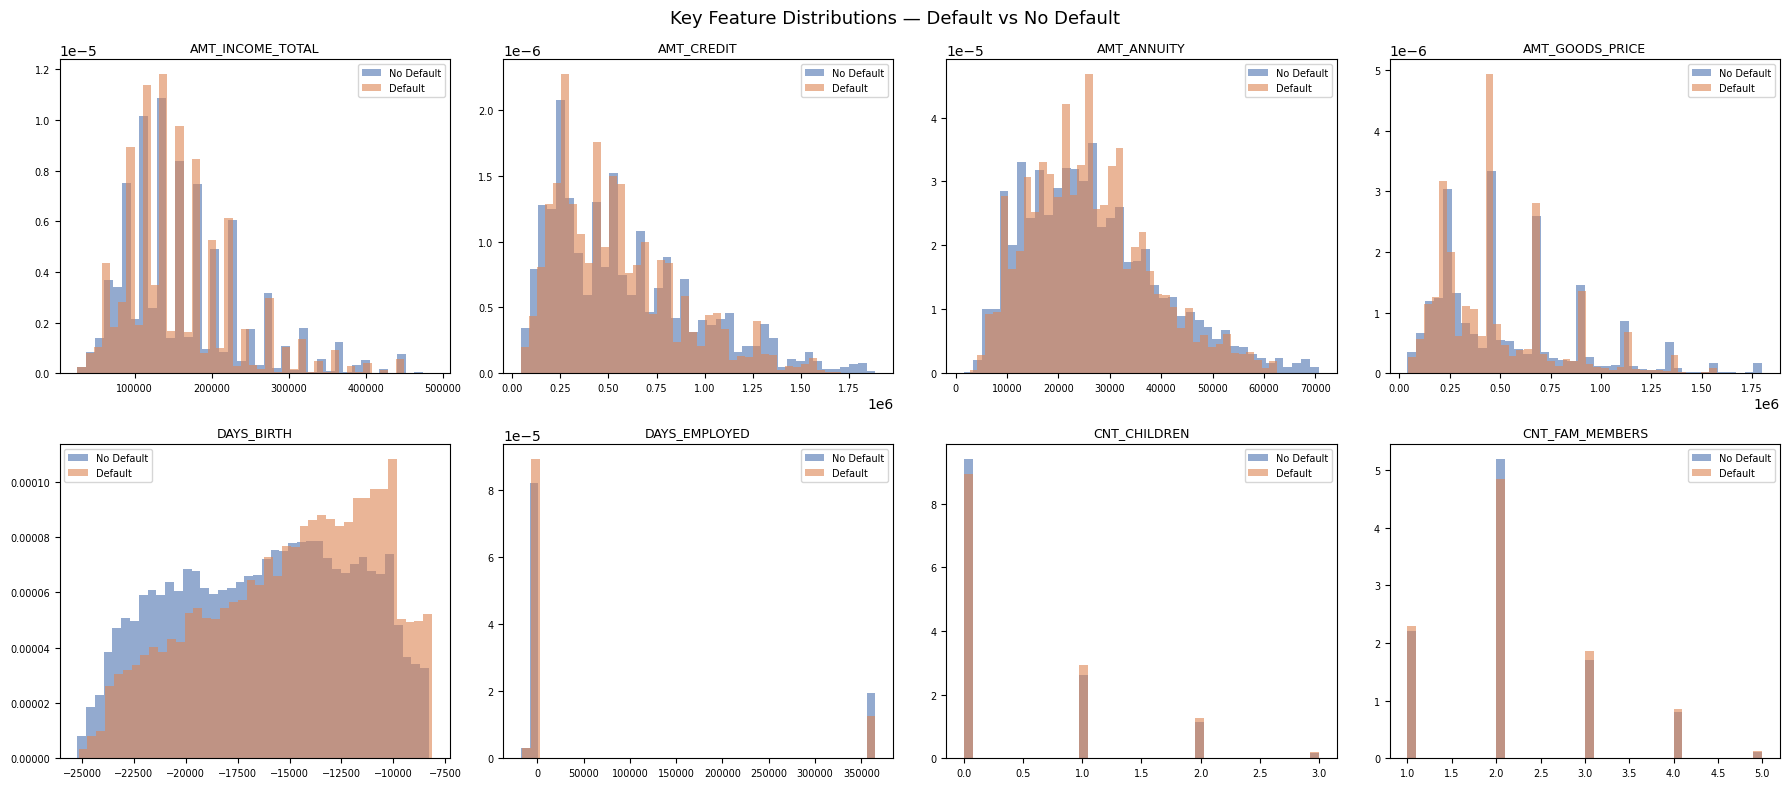

  Chart saved: feature_distributions.png


In [5]:
# ─────────────────────────────────────────────────────────────
# 2C. KEY NUMERICAL FEATURE DISTRIBUTIONS
# ─────────────────────────────────────────────────────────────

print("\n[2C] KEY NUMERICAL FEATURES — SUMMARY STATS")
print("-" * 40)

key_num_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "CNT_FAM_MEMBERS",
    "CNT_CHILDREN",
]

print(df[key_num_cols].describe().round(2).to_string())

# Plot distributions split by target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

plot_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
]

for i, col in enumerate(plot_cols):
    ax = axes[i]
    for target_val, color, label in [(0, "#4C72B0", "No Default"), (1, "#DD8452", "Default")]:
        subset = df[df["TARGET"] == target_val][col].dropna()
        # Cap extreme outliers for plotting only
        p99 = subset.quantile(0.99)
        subset = subset[subset <= p99]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Key Feature Distributions — Default vs No Default", fontsize=13)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: feature_distributions.png")

In [6]:
# ─────────────────────────────────────────────────────────────
# 2D. IMPORTANT DATA QUIRKS TO NOTE
# ─────────────────────────────────────────────────────────────

print("\n[2D] IMPORTANT DATA QUIRKS")
print("-" * 40)

# DAYS_BIRTH is negative (days before application = negative)
age_years = df["DAYS_BIRTH"].abs() / 365
print(f"\n  DAYS_BIRTH (stored as negative days):")
print(f"    Min age : {age_years.min():.1f} years")
print(f"    Max age : {age_years.max():.1f} years")
print(f"    Mean age: {age_years.mean():.1f} years")

# DAYS_EMPLOYED anomaly — 365243 is a known placeholder for retired/unemployed
employed_anomaly = (df["DAYS_EMPLOYED"] == 365243).sum()
print(f"\n  DAYS_EMPLOYED anomaly (value=365243 means unemployed/retired):")
print(f"    Count of anomalous rows : {employed_anomaly:,}")
print(f"    As % of dataset         : {employed_anomaly/len(df)*100:.1f}%")

# XNA in categorical columns
print(f"\n  'XNA' or 'Unknown' in categorical columns:")
for col in categorical_cols:
    xna_count = (df[col] == "XNA").sum()
    if xna_count > 0:
        print(f"    {col:<40} XNA count: {xna_count:,}")


[2D] IMPORTANT DATA QUIRKS
----------------------------------------

  DAYS_BIRTH (stored as negative days):
    Min age : 20.5 years
    Max age : 69.1 years
    Mean age: 43.9 years

  DAYS_EMPLOYED anomaly (value=365243 means unemployed/retired):
    Count of anomalous rows : 55,374
    As % of dataset         : 18.0%

  'XNA' or 'Unknown' in categorical columns:
    CODE_GENDER                              XNA count: 4
    ORGANIZATION_TYPE                        XNA count: 55,374



[2E] TOP 15 NUMERICAL FEATURES CORRELATED WITH TARGET
----------------------------------------

  Feature                                         |Correlation|
  --------------------------------------------------------------
  EXT_SOURCE_3                                           0.1789
  EXT_SOURCE_2                                           0.1605
  EXT_SOURCE_1                                           0.1553
  DAYS_BIRTH                                             0.0782
  REGION_RATING_CLIENT_W_CITY                            0.0609
  REGION_RATING_CLIENT                                   0.0589
  DAYS_LAST_PHONE_CHANGE                                 0.0552
  DAYS_ID_PUBLISH                                        0.0515
  REG_CITY_NOT_WORK_CITY                                 0.0510
  FLAG_EMP_PHONE                                         0.0460
  DAYS_EMPLOYED                                          0.0449
  REG_CITY_NOT_LIVE_CITY                                 0.0444
  FLAG

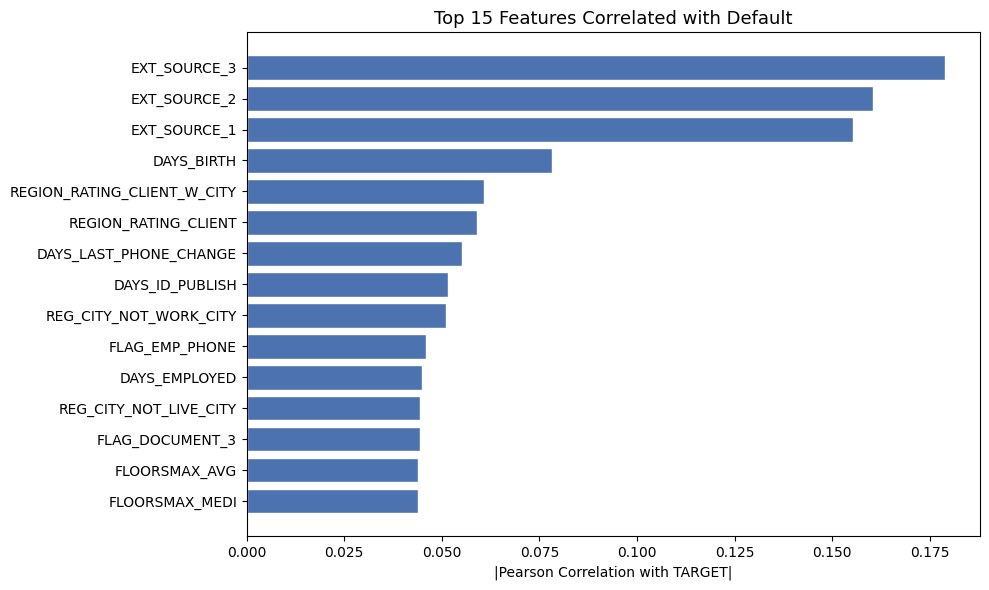

  Chart saved: correlation_with_target.png


In [7]:
# ─────────────────────────────────────────────────────────────
# 2E. CORRELATION WITH TARGET
# ─────────────────────────────────────────────────────────────

print("\n[2E] TOP 15 NUMERICAL FEATURES CORRELATED WITH TARGET")
print("-" * 40)

correlations = df[numerical_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET")
correlations = correlations.abs().sort_values(ascending=False)

print(f"\n  {'Feature':<45} {'|Correlation|':>15}")
print("  " + "-" * 62)
for feat, corr in correlations.head(15).items():
    print(f"  {feat:<45} {corr:>15.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
top15 = correlations.head(15)
ax.barh(
    top15.index[::-1],
    top15.values[::-1],
    color="#4C72B0", edgecolor="white"
)
ax.set_xlabel("|Pearson Correlation with TARGET|")
ax.set_title("Top 15 Features Correlated with Default", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_with_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: correlation_with_target.png")




[2F] CATEGORICAL FEATURES — DEFAULT RATE BY CATEGORY
----------------------------------------


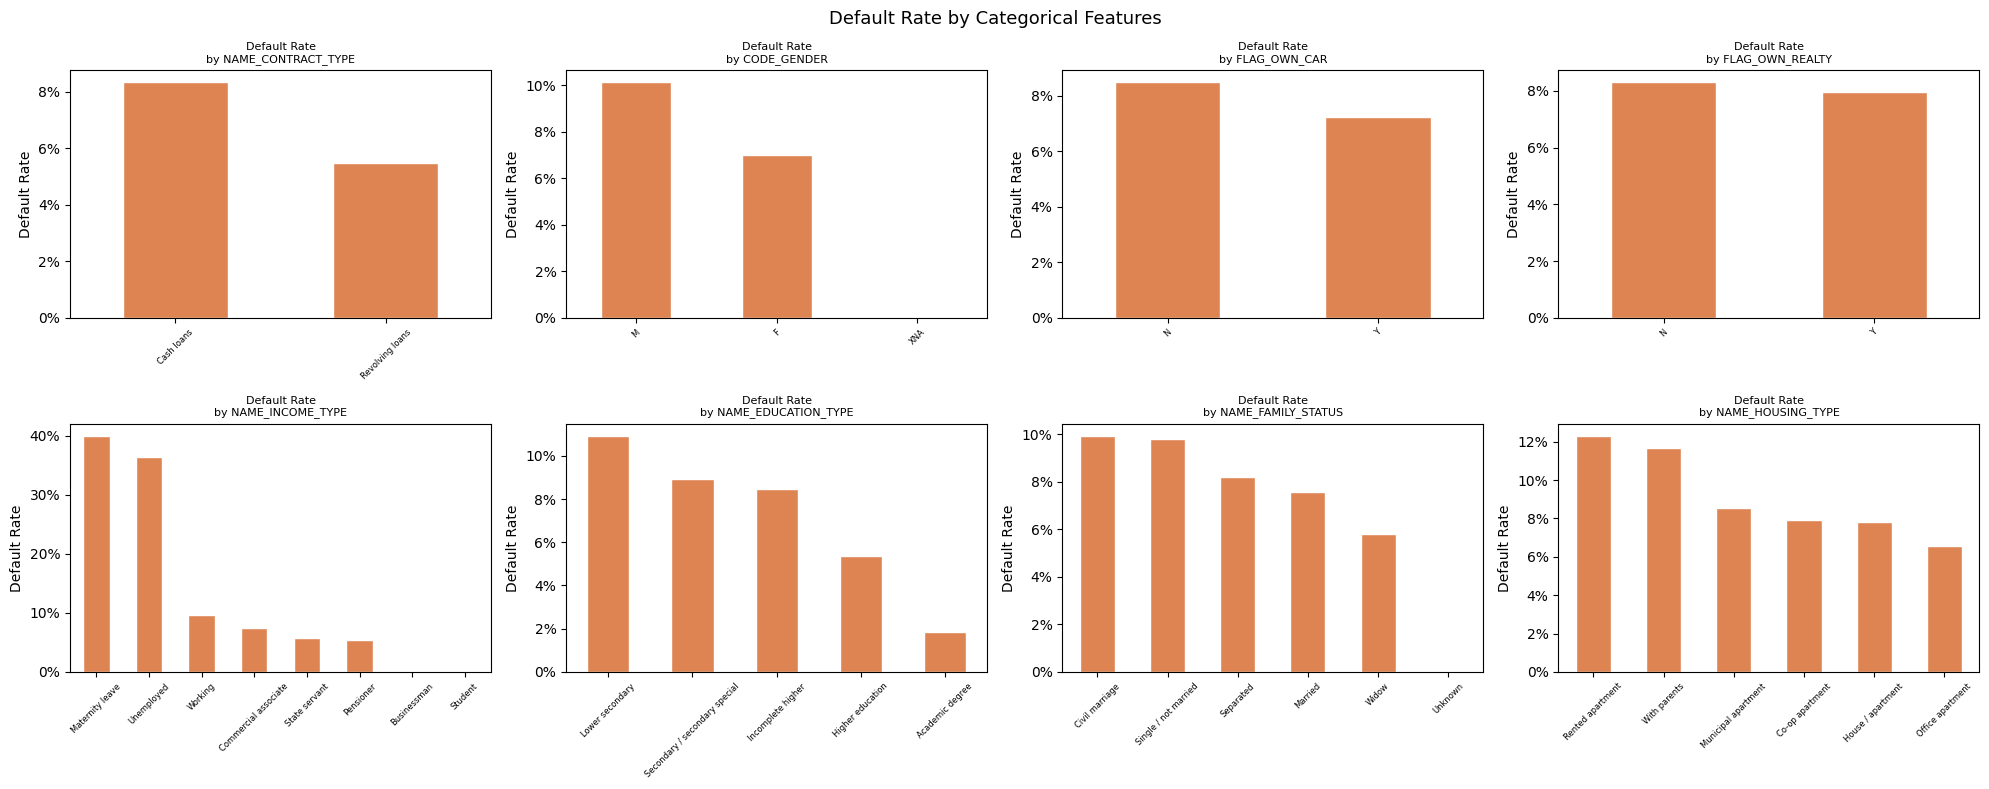

  Chart saved: categorical_default_rates.png


In [8]:
# ─────────────────────────────────────────────────────────────
# 2F. CATEGORICAL FEATURE ANALYSIS
# ─────────────────────────────────────────────────────────────

print("\n[2F] CATEGORICAL FEATURES — DEFAULT RATE BY CATEGORY")
print("-" * 40)

key_cat_cols = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(key_cat_cols):
    ax = axes[i]
    default_rate_by_cat = (
        df.groupby(col)["TARGET"]
        .mean()
        .sort_values(ascending=False)
        .head(8)
    )
    default_rate_by_cat.plot(
        kind="bar", ax=ax,
        color="#DD8452", edgecolor="white"
    )
    ax.set_title(f"Default Rate\nby {col}", fontsize=8)
    ax.set_ylabel("Default Rate")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=6, rotation=45)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.0%}")
    )

plt.suptitle("Default Rate by Categorical Features", fontsize=13)
plt.tight_layout()
plt.savefig("categorical_default_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: categorical_default_rates.png")

# SUMMARY OF KEY RISKS


=============================================================
STEP 2 SUMMARY — KEY DATA RISKS IDENTIFIED
=============================================================

1. CLASS IMBALANCE (8.07% defaults)
   → Accuracy is misleading. Use AUC + KS.
   → Will use class_weight='balanced' in models.

2. MISSING VALUES
   → Many columns have 40-70% missing (e.g. OWN_CAR_AGE).
   → Strategy: median imputation + missing indicator flag.

3. DAYS_EMPLOYED ANOMALY
   → Value 365243 = unemployed/retired placeholder.
   → Must replace with NaN before any modeling.

4. DAYS_BIRTH IS NEGATIVE
   → Convert to positive age in years for interpretability.

5. XNA IN CATEGORICAL COLUMNS
   → Treat XNA as a separate valid category or as missing.

6. OUTLIERS IN INCOME / CREDIT
   → Some incomes are extremely high (data entry errors).
   → Will cap at 99th percentile during cleaning.

7. LOW RAW CORRELATIONS
   → No single feature has correlation > 0.15 with TARGET.
   → Tree-based models + feature interactions will be key.
=============================================================